# Vector Geometry and Topological Foundations for Deep Learning

## Introduction: The Algebraic Architecture of Neural Networks

The theoretical scaffolding of modern deep learning rests entirely upon the axiomatic foundations of linear algebra, multivariable calculus, and high-dimensional geometry. At its most fundamental level, machine learning is the science of manipulating, transforming , and optimising high-dimensional representations of data. These representations, whether they encode the semantic meaning of text sequences in natural language processing or the spatial hierarchies of pixels in computer vision, exist strictly as mathematical vectors mapped into highly structured coordinate systems. Consequently, understanding the mechanics of deep learning requires a profound fluency in the geometry of vector spaces, the topological implications of distance metrics, the projective nature of vector multiplication, and the calculus of high-dimensional optimisation.<br><br>
This comprehensive analysis explores the foundational mechanics of vector spaces, linear combinations, and norms. It rigorously derives the mathematical principles that dictate the trajectory of optimisation algorithms, specifically examining why gradient descent operates optimally in the direction of the negative gradient through the lens of directional derivatives and the dot product. Furthermore, the analysis bridges theoretical mathematics with practical computational deployment by detailing the explicit implementation of fundamental vector operations utilizing pure computational logic, demonstrating how these geometric abstractions govern neural network embeddings, similarity metrics, and loss geometries.

## The Axiomatic Foundations of Vector Spaces and Feature Geometries

To comprehend how neural networks process information, one must first define the mathematical arena in which this processing occurs : the vector space, or linear space, is a fundamental mathematical structure consisting of collection of vectors equipped with two primary operations: **vector addition** and **scalar multiplication**. For a set of elements to qualify formally as a vector space, these operations must satisfy a strict set of axioms that guarantee the algebraic stability of the space.<br><br>
The most common vector spaces utilized in deep learning are denoted by $\mathbb R^n$, representing a real coordinate space consisting three-dimensional space, while $\mathbb R^{1024}$ might represent the highly dimensional latent space of a large language model. Complex vector spaces, denoted as $\mathbb{C}^n$, are also utilized in specific signal processing networks where the components are complex numbers. A subset of vector space that is itself a vector space is known as a subspace , the set must contain the zero vector and remain closed under both vector addition and scalar multiplication.

| Axiom Category  | Specific Axiom        | Mathematical Formulation | Implications for Neural Networks |
|-----------------|----------------------|--------------------------|----------------------------------|
| Addition        | Commutativity        | u + v = v + u            | Order of feature aggregation does not alter the geometric resultant. |
| Addition        | Associativity        | (u + v) + w = u + (v + w) | Sequential aggregation of gradient updates is algebraically stable. |
| Identity        | Additive Identity    | v + 0 = v                | Existence of a zero vector allows for zero-state initializations and dropouts. |
| Inverses        | Additive Inverse     | v + (−v) = 0             | Enables gradient descent updates to perfectly reverse specific feature directions. |
| Multiplication  | Scalar Distributivity| c(u + v) = cu + cv       | Scaling a batch of aggregated features is equivalent to scaling them individually. |
| Multiplication  | Vector Distributivity| (c + d)v = cv + dv       | Learning rate modifications apply uniformly across the vector's trajectory. |

In the context of deep learning, these formal spaces translate directly into what practitioners call "feature spaces" or "latent spaces." A single data point, such as a digitized image, an audio waveform, or tokenized word, is numerically encoded as a vector $v \to \mathbb R^n$, where the dimensionality n represents the number of independent features or latent variables characterising that data. In natural language processing, this manifests prominently as word embeddings. Deep learning architectures like Word2Vec explicitly map discrete words into continuous high-dimensional vector spaces such that semantic meanings are encoded as spatial geometries. The famous vector arithmetic $\mathbf{v}_{king} - \mathbf{v}_{man} + \mathbf{v}_{woman} \approx \mathbf{v}_{queen}$ is a direct consequence of representing semantic concepts as coordinate points in a strictly governed vector space where distances and directions possess interpretable value.

### Linear Combinations, Span, and Representational Capacity

A fundamental operation within any vector space is the linear combination. Given a set of vectors $\{\mathbf{v}_1, \mathbf{v}_2, \dots, \mathbf{v}_k\}$ and a corresponding set of scalar weights $\{w_1, w_2, \dots, w_k\}$, a linear combination is defined algebraically as $\mathbf{u} = w_1\mathbf{v}_1 + w_2\mathbf{v}_2 + \dots + w_k\mathbf{v}_k$.<br><br>
The concept of "span" is intrinsically linked to linear combinations. The span of a set of vectors is defined mathematically as the collection of all possible vectors that can be generated by forming every conceivable linear combination of the vectors in that specific set. Geometrically, the span represents the smallest subspace that the vectors "sweep out" or cover within the parent vector space. For example, a single non-zero vector in three-dimensional space spans a one-dimensional line projecting infinitely from the origin. Two linearly independent vectors span a two-dimensional plane.<br><br>
In artificial neural networks, the concept of span fundamentally dictates the representational capacity of a given layer. A standard dense (fully connected) layer computes its pre-activation output by taking a linear combination of its input features, weighted by the learned parameter matrix. The column space of this weight matrix-the subspace spanned by its column vectors - determines the exact topological constraints of the features the layer can effectively represent and transmit to subsequent layers. If a system exists within the column space of the weight matrix $\mathbb A$.

#### **Linear Combination and Span Examples in $\mathbb{R}^3$**

#### **1. Linear Combination Example**

Let

$$
\mathbf{v}_1 =
\begin{bmatrix}
1\\
0\\
2
\end{bmatrix},
\quad
\mathbf{v}_2 =
\begin{bmatrix}
-1\\
3\\
1
\end{bmatrix}
$$

Choose scalars $w_1 = 2$, $w_2 = -1$.

$$
\mathbf{u} = 2\mathbf{v}_1 - \mathbf{v}_2
$$

$$
=
\begin{bmatrix}
2\\
0\\
4
\end{bmatrix}
+
\begin{bmatrix}
1\\
-3\\
-1
\end{bmatrix}
=
\begin{bmatrix}
3\\
-3\\
3
\end{bmatrix}
$$

Thus, $\mathbf{u}$ is a linear combination of $\mathbf{v}_1$ and $\mathbf{v}_2$.

---

#### **2. Span of One Vector (Line)**

Let

$$
\mathbf{v} =
\begin{bmatrix}
2\\
1\\
0
\end{bmatrix}
$$

$$
\text{span}\{\mathbf{v}\}
=
\left\{
c
\begin{bmatrix}
2\\
1\\
0
\end{bmatrix}
\mid c \in \mathbb{R}
\right\}
$$

This represents a line through the origin.

---

#### **3. Span of Two Vectors (Plane)**

Let

$$
\mathbf{v}_1 =
\begin{bmatrix}
1\\
0\\
0
\end{bmatrix},
\quad
\mathbf{v}_2 =
\begin{bmatrix}
0\\
1\\
0
\end{bmatrix}
$$

$$
\text{span}\{\mathbf{v}_1,\mathbf{v}_2\}
=
\left\{
a
\begin{bmatrix}
1\\
0\\
0
\end{bmatrix}
+
b
\begin{bmatrix}
0\\
1\\
0
\end{bmatrix}
\mid a,b \in \mathbb{R}
\right\}
$$

$$
=
\left\{
\begin{bmatrix}
a\\
b\\
0
\end{bmatrix}
\mid a,b \in \mathbb{R}
\right\}
$$

This represents the $xy$-plane.

---

#### **4. Span of Three Vectors (Entire Space)**

$$
\mathbf{v}_1 =
\begin{bmatrix}
1\\
0\\
0
\end{bmatrix},
\quad
\mathbf{v}_2 =
\begin{bmatrix}
0\\
1\\
0
\end{bmatrix},
\quad
\mathbf{v}_3 =
\begin{bmatrix}
0\\
0\\
1
\end{bmatrix}
$$

$$
\text{span}\{\mathbf{v}_1,\mathbf{v}_2,\mathbf{v}_3\}
=
\left\{
\begin{bmatrix}
a\\
b\\
c
\end{bmatrix}
\mid a,b,c \in \mathbb{R}
\right\}
=
\mathbb{R}^3
$$

#### Linear Combination in $\mathbb R^2$ : Python Visualisation


[0.5 2.5]


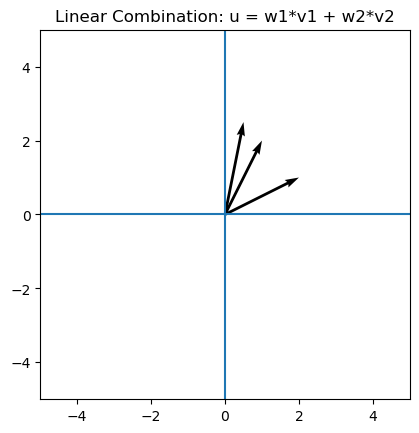

In [3]:
import numpy as np
import matplotlib.pyplot as plt

# Define vectors
v1 = np.array([1,2])
v2 = np.array([2,1])

# Example weights 
w1, w2 = 1.5, -0.5

# Linear combination
u = w1 * v1 + w2*v2
print(u)
# Plot setup 
plt.figure()
plt.axhline(0)
plt.axvline(0)

# Plot vectors
plt.quiver(0, 0, v1[0], v1[1], angles='xy', scale_units='xy', scale=1)
plt.quiver(0, 0, v2[0], v2[1], angles='xy', scale_units='xy', scale=1)
plt.quiver(0, 0, u[0], u[1], angles='xy', scale_units='xy', scale=1)

plt.xlim(-5, 5)
plt.ylim(-5, 5)
plt.gca().set_aspect('equal')

plt.title("Linear Combination: u = w1*v1 + w2*v2")
plt.show()

#### Span of One Vector (Line)

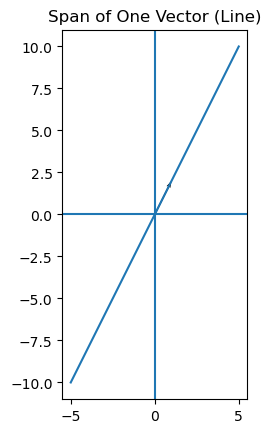

In [5]:
# Scalars
weights = np.linspace(-5, 5, 100)

# Generate points
line_points = np.array([w * v1 for w in weights])

plt.figure()
plt.axhline(0)
plt.axvline(0)

plt.plot(line_points[:,0], line_points[:,1])
plt.quiver(0, 0, v1[0], v1[1], angles='xy', scale_units='xy', scale=1)

plt.gca().set_aspect('equal')
plt.title("Span of One Vector (Line)")
plt.show()

#### Span of Two Independent Vectors (Plane)

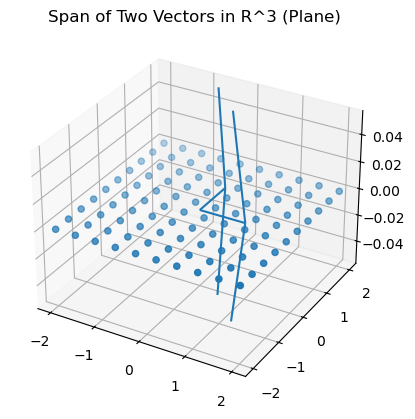

In [6]:
from mpl_toolkits.mplot3d import Axes3D

v1 = np.array([1, 0, 0])
v2 = np.array([0, 1, 0])

w = np.linspace(-2, 2, 10)
W1, W2 = np.meshgrid(w, w)

# Linear combinations
plane_points = np.array([
    w1 * v1 + w2 * v2
    for w1, w2 in zip(W1.flatten(), W2.flatten())
])

fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')

ax.scatter(plane_points[:,0], plane_points[:,1], plane_points[:,2])
ax.quiver(0,0,0,v1[0],v1[1],v1[2])
ax.quiver(0,0,0,v2[0],v2[1],v2[2])

ax.set_title("Span of Two Vectors in R^3 (Plane)")
plt.show()

#### Column Space of a Matrix (Neural Network Connection)

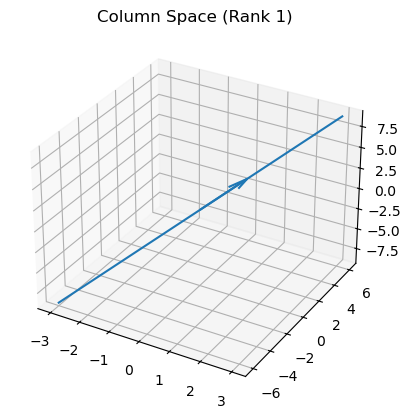

In [7]:
A = np.array([
    [1, 2],
    [2, 4],
    [3, 6]
])

col1 = A[:,0]

weights = np.linspace(-3, 3, 50)
points = np.array([w * col1 for w in weights])

fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')

ax.plot(points[:,0], points[:,1], points[:,2])
ax.quiver(0,0,0,col1[0],col1[1],col1[2])

ax.set_title("Column Space (Rank 1)")
plt.show()

### Linearly Independent Bases and Degrees of Freedom

A subset of vectors forms a "basis" for a vector space if it strictly satisfies two geometric conditions: the vectors must span the entire vector space (or subspace) , and they must be linearly independent. Linear independence implies a total lack of redundancy; no single vector in the set can be constructed as a linear combination of the others. Consequently, a basis provides a unique coordinate system for the data, ensuring that every vector within the space can be expressed in one, and only one, way as combination of the basis vectors.<br><br>
The number of vectors in a basis defines the dimension of the vector space. In deep learning, the dimension corresponds to the "degrees of freedom" or the minimum number of independent orthogonal directions required to accurately capture the variance and structure of the dataset. Dimensionality reduction algorithms and autoencoders are explicitly designed to find a lower-dimensional basis-a compressed latent space- that captures the fundamental manifold of the data while discarding noise. By mapping data from a high-dimensional space to a lower-dimensional basis, the network learns the intrinsic, non-redundant properties of the distribution.

## Norms: The Geometry of Distance and Regularisation

If vector spaces define the structural arena of deep learning, norms provide the absolute metric of distance, magnitude, and size within the arena. A norm is a mathematical function that assigns a strictly positive length to a vector, serving as a generalisation of the concept of physical distance. In machine learning, calculating the size of a vector is essential for evaluating model errors through loss functions and for constraining parameter spaces to prevent overfitting through a process known as regularisation.

### Mathematical Definitions of the L1, L2, and L-Infinity Norms

The generalised $L_p$ norm (or p-norm) of a vector $\mathbf{x} = [x_1, x_2, \dots, x_n]^T$ is mathematically defined as : 
$$||\mathbf{x}||_p = \left( \sum_{i=1}^n |x_i|^p \right)^{\frac{1}{p}}$$
By altering the parameter p, entirely different geometric properties and topologies are induced upon the vector space.<br><br>
Setting $p=1$ yields the $L_1$ norm. It is calculated as the simple sum of the absolute values of the vector components: $||\mathbf{x}||_1 = \sum_{i=1}^n |x_i|$. Geometrically, this represents the distance between two points measured along axes at strictly right angles, colloquially referred to as the Manhattam distance or taxicab norm because it mimics a vehicle navigating a rigid city grid.<br><br>
Setting $p=2$ yields the $L_2$ norm, which is by far the most ubiquitous norm in scientific computing. It is the square root of the sum of the squared vector values: $||\mathbf{x}||_2 = \sqrt{\sum_{i=1}^n x_i^2}$. 
This represents the shortest straight-line physical distance between the origin and the point in Euclidean space, hence its alternative designation as the Euclidean norm.<br><br>
As $p$ approaches infinity ($p \to \infty$), the norm evaluates to the $L_\infty$ norm, also known as the max norm. It is defined solely by the single vector component that possess the largest absolute value: $||\mathbf{x}||_\infty = \max(|x_1|, |x_2|, \dots, |x_n|)$.

### Geometric Interpretation and the Unit Ball 


The geometric implications of these norms are best visualised by examining their "unit ball." The unit ball is the topological set of all vectors in a given space whose norm is exactly equal to 1. In a standard two-dimensional plane, the unit balls for different norms exhibit radically different shapes. <br><br>
The $L_2$ unit ball forms a perfect, isotropic circle; every point on the circumference is equidistant from the origin in a straight line. The $L_1$ unit ball, however, takes the shape of a rotated square or a diamon. Its vertices lie exactly on the coordinate axes. The $L_\infty$ unit ball forms a standard , non-rotated square (or a hypercube in higher dimensions) where the maximum coordinate value never exceeds 1. There also exists the theoretical $L_0$ "norm," which simply counts the number of non-zero components in a vector. The $L_0$ "norm," which simply counts the number of non-zero components in a vector. The $L_0$ unit ball consists only of the points lying directly on the coordinate axes, forming a non-convex cross shape. Because $L_0$ optimisation is computationally intractable (NP-hard), the $L_1$ norm is universally employed as the tightest convex relaxation of the $L_0$ norm for practical variable selection.
| Norm Type | Mathematical Formulation | Unit Ball Geometry in ℝ² | Primary Regularization Effect | Deep Learning Application |
|-----------|--------------------------|---------------------------|--------------------------------|----------------------------|
| L0 "Norm" | $\sum_{i} \mathbb{I}(x_i \neq 0)$ | Cross lying exactly on coordinate axes | Optimal but computationally intractable subset selection | Theoretical variable selection, compressed sensing |
| L1 Norm | $\|\mathbf{x}\|_1 = \sum_{i} |x_i|$ | Diamond (Cross-polytope) | Induces sparsity; forces non-essential weights exactly to zero | Feature selection, LASSO regression, sparse autoencoders |
| L2 Norm | $\|\mathbf{x}\|_2 = \sqrt{\sum_{i} x_i^2}$ | Perfect circle / hypersphere | Induces weight decay; shrinks all weights symmetrically | Ridge regression, standard neural network weight decay |
| Max Norm ($L_\infty$) | $\|\mathbf{x}\|_\infty = \max_i |x_i|$ | Axis-aligned square / hypercube | Caps the absolute maximum allowable weight magnitude | Max-norm regularization in deep layers, adversarial robustness |

### Regularisation and the Topology of the Loss Landscape

These distinct topological geometries have profound implications when applied as regularisation penalties in machine learning. Regularisation is a technique utilised to constraint the complexity of a model, penalising abnormally large weights to prevent the network from overfitting to the training data's noise.
<br><br>
When optimising a loss function combined with an $L_1$ penalty, the parameter updates traverse the loss landscape toward the constrained regions. Because the $L_1$ unit ball possesses sharp corners located exactly on the coordinate axes, the elliptical contours of the unregularised loss function are statistically highly likely to intersect the $L_1$ penalty boundary precisely at one of these corners. When an intersection occurs at a corner, the corresponding weight component is exactly zero. This is the geometric reason why $L_1$ regularisation inherently performs variable selection, yielding highly sparse neural networks.<br><br>
Conversely, the $L_2$ norm, being perfectly round, lacks corners. Intersections between the loss contours and the $L_2$ unit ball almost universally occur at non-zero coordinates. Consequently, while the weights are uniformly scaled down (weight decay), they are rarely driven entirely to zero.<br><br>
Furthermore, the choice of norm actively alters the fundamental geometry of the loss landscape itself. Models utilising $L_2$ norms often present smoother, more isotropic loss topographies that are highly conductive to gradient-based optimisation. In contrast, incorporating non-standard topological constraints can create jagged, complex optimisation surfaces rife with varied critical points, saddle points, and asymmetrical minima, requiring specialised optimisers.

## The Dot Product, Angular Similarity, and Projections

The dot product (or inner product) is arguably the single most pervasive mathematical operation in the entirely of deep learning architecture. It serves as the fundamental mechanism by which neural networks align information, measure feature similarity, filter signals, and project data into distinct representations. 

### Algebraic and Geometric Dualities

For two vectors $\mathbf{a} = [a_1, a_2, \dots, a_n]$ and $\mathbf{b} = [b_1, b_2, \dots, b_n]$ existing in $\mathbb R^n$, the dot product is defined algebraically as the sum of the products of their corresponding individual components : 
$$\mathbf{a} \cdot \mathbf{b} = \sum_{i=1}^n a_i b_i$$
However, its geometric definition reveals its true analytical power and explains its ubiquity in machine learning. The dot product is simultaneously defined as the product of the Euclidean magnitueds ($L_2$ norms) of the two vectors multiplied by the cosine of the angle $\theta$ separating them in high-dimensional space : 
$$\mathbf{a} \cdot \mathbf{b} = ||\mathbf{a}||_2 ||\mathbf{b}||_2 \cos(\theta)$$
<br>
This geometric equivalence establishes the dot product as a highly efficient mechanism to measure vector alignment. It answers a fundamental question inherent to pattern recognition: "How much of vector **a** points in the exact direction of **b**?". If two vectors point in almost the exact same direction, the angle $\theta$ is small, the cosine approaches 1, and the dot product yields a large positive same, direction, the angle $\theta$ is small, the cosine approaches 1, and the dot product yields a large positive value, indicating strong alignment. If they point in opposite directions, the angle is greater than $90^\circ$ , the cosine is negative, and the dot product is negative. Crucially, if the vectors are perfectly perpendicular ($\theta = 90^\circ$) , the cosine is exactly 0, and the dot product evaluates to 0, indicating zero alignment or complete orthogonality.

### Deriving Vector Projections

The concept of projection is deeply reliant on the dot product. The scalar projection of vector **u** onto vector **v** represents the exact magnitude of the "shadow" that **u** casts upon **v** if a perpendicular light source were applied. Mathematically, this scalar distance is calculated as $||\mathbf{u}|| \cos(\theta)$. By algebraically rearranging the geometric definition of the dot product, ew can isolate this term, proving that the scalar projection is precisely  $\frac{\mathbf{u} \cdot \mathbf{v}}{||\mathbf{v}||}$.<br>
However, in neural networks, we often require the actual vector projection - a new vector pointing in the exact direction of **v** but possessing the magnitude of the scalar projection. To construct this, one takes the scalar projection and multiplies it by the normalised unit vector of **v**, which is $\frac{\mathbf{v}}{||\mathbf{v}||}$: 
$$\text{proj}_{\mathbf{v}}\mathbf{u} = \left( \frac{\mathbf{u} \cdot \mathbf{v}}{||\mathbf{v}||} \right) \frac{\mathbf{v}}{||\mathbf{v}||} = \left( \frac{\mathbf{u} \cdot \mathbf{v}}{||\mathbf{v}||^2} \right) \mathbf{v}$$
Because $||\mathbf{v}||^2$ is algebraically equivalent to the dot product of **v** with itself (**v.v**), the vector projection formula can also be written purely in terms of dot products: $\text{proj}_{\mathbf{v}}\mathbf{u} = \frac{\mathbf{u} \cdot \mathbf{v}}{\mathbf{v} \cdot \mathbf{v}} \mathbf{v}$.

### Cosine Similarity and Self-Attention Mechanisms

If one wishes to measure pure directional alignment devoid of magnitude bias, the vectors must be normalised. By dividing the dot product by the product of the individual magnitudes, the magnitudes mathematically cancel out, isolating the cosine of the angle alone:
$$\text{Cosine Similarity}(\mathbf{a}, \mathbf{b}) = \cos(\theta) = \frac{\mathbf{a} \cdot \mathbf{b}}{||\mathbf{a}||_2 ||\mathbf{b}||_2}$$
This yields a similarity score that is tightly bounded betwee -1 (perfect opposition) and 1 (perfect identical alignment).
<br>
In a standard feedforward neural network, the computation within a single artificial neuron is structurally a dot product. A neuron receives an input vector **x**, applies a learned vector **w**, and adds a scalar bias b. The pre-activation output $y = w.x+b$ is essentially the network projecting the input data onto the learned weight vector. If the input highly aligns with the weight vector's learned pattern, the dot product is large, and the neuron activates strongly.<br>
<br>
This geometric alignment property is the central operating principle of the Self-Attention mechanism, the architectural foundation of modern Transformer models such as Large Language Models. In self-attention, input word embeddings are linearly transformed into three distinct representations: Query($Q$), Key ($K$), and Value($V$) matrices. The model must determine how much focus (attention) a given word should place on every other word in the sequence. The attention score between a specific query vector and a key vector is computed directly via their dot product : $QK^T$. <br><br>
Despite the standard dot product yielding an unnormalised scalar with no predefined bounds, it is vastly preferred over pure cosine similarity in self-attention because it concurrently measures both the directional alignment (semantic similarity) and the mathematical magnitude (importance / confidence) of the vectors. A high dot product indicates that a specific query token is highly relevant to a specific key token, prompting the network to assign it a massive structural weight after the scores are scaled down by the square root of the dimension ($\sqrt{d_k}$) and passed through softmax normalisation function.

## Orthogonality in Optimisation and Decorrelation

The concept of orthogonality - vectors possessing a dot product of exactly zero - extends far beyond basic geometric perpendicularity in a 2D plane. In the hyper-dimensional optimisation spaces of deep learning, orthogonality represents independent, non-overlapping information transfer, which is mathematically vital for model stability and efficiency.

### Mitigating Vanishing and Exploding Gradients via Dynamically Isometry 

A critical vulnerability in training deep networks, particularly Recurrent Neural Networks (RNNs) and exceptionally deep Multi-Layer Perceptrons (MLPs), is the vanishing or exploding a gradient problem. During the backpropagation of errors, gradients are repeatedly multiplied by the network's consecutive weight matrices. If the eignevalues of these weight matrices are strictly greater than 1, the gradients compound exponentially and explode into computational infintiy (NaN values); if they are less than 1, the gradients compound fractionally and vanish, halting all learning entirely in the earlier layers. <br><br>
Orthogonal initialisation provides an elegant, geometrically sound remedy. By initialising the initial weight matrices as orthogonal matrices - where the transpose of the matrix is equal to its inverse, such that $\mathbf{W}^T \mathbf{W} = \mathbf{I}$ -- the network intrinsically preserves vector lengths and inter-vector angles during matrix multiplication. The eigenvalues of a perfectly orthogonal matrix have an absolute value of exactly 1. Therefore, when gradients backpropagate through dozens or hundreds of layers that have been initialised orthogonally, their magnitudes neither vanish nor explode. This mathematical phenomena, known as dynamical isometry, speeds up convergence dramatically, improves conditioning, and stabilises signal flow across exceptionally deep architectures. In practice, orthogonal matrices for initialisation are generated by drawing a random matrix from a normal distribution and performing a QR decomposition ($\mathbf{X} = \mathbf{Q}\mathbf{R}$) or Singular Value Decomposition (SVD), utilising the resulting orthogonal $Q$ or $U$ matrix as the network weights.

### Decorrelating Features and Enforcing Diversity 

Beyond initialisation, orthogonality is frequently enforced dynamically during the training process itself via orthogonal projection losses or regularisation penalties. Deep networks, particularly Convolutional Neural Networks (CNNs), are highly prone to learning redundant features due to massive over-parameterisation; multiple conolutional filters may converge to detect the exact same visual pattern, wasting computational capacity.<br><br>
To maximise the representational capacity of the model, practitioners apply a diversity regularisation term that actively penalises high cosine similarities between feature vectors. By minimising the pairwise dot products between weight vectors or filters, the network explicitly forces the vectors toward orthogonality. Geometrically, this optimsation distributes the weight vectors uniformly across the surface of a high-dimensional hypersphere (a configuration inspired by the Tammes problem), ensuring that each individual neuron captures highly discriminative, mutually exclusive , and complementary information.

## Rigorous Mathematical Derivation of the Squared L2 Norm Gradient

Understanding the foundational calculus of vector norms is an absolute prerequire to understanding optimisation in deep learning. To minimise a loss function utilising standard $L_2$ regularisation (weight decay), the optimiser must dynamically compute the gradient of the squared $L_2$ norm, denoted as $\nabla ||\mathbf{x}||_2^2$. The derivation of this gradient can be proved through four distinct mathematical frameworks.
| Derivation Method | Core Mathematical Principle | Gradient Result |
|-------------------|----------------------------|-----------------|
| Component-wise Partial Derivatives | Expand summation and apply scalar power rule to each coordinate. | $\nabla f(\mathbf{x}) = 2\mathbf{x}$ |
| Finite Differences | Take the limit of the difference quotient using inner products. | $\nabla f(\mathbf{x}) = 2\mathbf{x}$ |
| Matrix Differential Calculus | Use differentials of vector products: $dy = dx^T \mathbf{x} + \mathbf{x}^T dx$. | $\nabla_{\mathbf{x}} y = 2\mathbf{x}$ |
| Differentiability Definition | Isolate the linear mapping $L(\mathbf{h})$ from the higher-order error term $o(\mathbf{h})$. | $\nabla f(\mathbf{x}) = 2\mathbf{x}$ |"

### Method 1 : Component-wise Partial Derivatives

Let the objective function be defined as $f(\mathbf{x}) = ||\mathbf{x}||_2^2$ for a vector $\mathbf{x} \in \mathbb{R}^n$. By the fundamental summation definition of the Euclidean norm, this is the sum of the squares of its $n$ components:$$f(\mathbf{x}) = \sum_{k=1}^n x_k^2$$
To construct the complete gradient vector, we must find the partial derivative of $f(x)$ with respect to a single arbitrary component, $x_j$ :$$\frac{\partial}{\partial x_j} f(\mathbf{x}) = \frac{\partial}{\partial x_j} \sum_{k=1}^n x_k^2$$
Because mathematical differentiation is a linear operator, the derivative of a sum is equal to the sum of the derivatives. We distribute the partial derivative inside the summation : 
$$\sum_{k=1}^n \frac{\partial}{\partial x_j} (x_k^2)$$
Crucially, the vector components are independent variables. When talking the partial derivative with respect to $x_j$, any term where $k!=j$ is treated mathematically as a constant, and the derivative of a constant is exactly 0. The only non-zero term occurs precisely when $ k = j$ . Using the standard power rule of calculus: 
$$\frac{\partial}{\partial x_j} (x_j^2) = 2x_j$$
Therefore, the partial derivative for any given component $x_j$ is simply $2x_j$. Assembling these scalar partial derivatives back into a full gradient column vector yields: 
$$\nabla f(\mathbf{x}) = \begin{bmatrix} 2x_1 \\ 2x_2 \\ \vdots \\ 2x_n \end{bmatrix} = 2 \begin{bmatrix} x_1 \\ x_2 \\ \vdots \\ x_n \end{bmatrix} = 2\mathbf{x}$$
Thus, the gradient of the squared $L_2$ norm is conclusively $2x$.

### Method 2: Inner Product and Finite Differences

This approach utilizes the direct connection between the norm and the inner product, expressed as $||\mathbf{x}||^2 = (\mathbf{x},\mathbf{x})$.
We evaluate the difference between the squared norm at a perturbed point $\mathbf{x} + s\mathbf{h}$ (where $s$ is an infinitesimal scalar step size and $\mathbf{h}$ is a direction vector) and the original point $\mathbf{x}$ :$$||\mathbf{x}+s\mathbf{h}||^2 - ||\mathbf{x}||^2 = (\mathbf{x}+s\mathbf{h}, \mathbf{x}+s\mathbf{h}) - (\mathbf{x},\mathbf{x})$$Expanding the inner product utilizing its bilinear properties yields:$$(\mathbf{x},\mathbf{x}) + s(\mathbf{x},\mathbf{h}) + s(\mathbf{h},\mathbf{x}) + s^2(\mathbf{h},\mathbf{h}) - (\mathbf{x},\mathbf{x})$$$$= 2s(\mathbf{x},\mathbf{h}) + s^2(\mathbf{h},\mathbf{h})$$The gradient acting in direction $\mathbf{h}$ is defined as the limit of this difference quotient as the step size $s$ approaches zero :$$(\nabla||\mathbf{x}||^2, \mathbf{h}) = \lim_{s \to 0} \frac{1}{s}\left[2s(\mathbf{x},\mathbf{h}) + s^2(\mathbf{h},\mathbf{h})\right]$$$$= \lim_{s \to 0} \left[2(\mathbf{x},\mathbf{h}) + s(\mathbf{h},\mathbf{h})\right]$$As $s \to 0$, the $s(\mathbf{h},\mathbf{h})$ term vanishes entirely, leaving $2(\mathbf{x},\mathbf{h})$, which is algebraically equivalent to $(2\mathbf{x},\mathbf{h})$. Because this equality $(\nabla||\mathbf{x}||^2, \mathbf{h}) = (2\mathbf{x},\mathbf{h})$ holds true for any arbitrary direction vector $\mathbf{h}$, the gradient vector must be exactly $\nabla ||\mathbf{x}||^2 = 2\mathbf{x}$.

### Method 3 : Matrix Differential Calculus

The derivation can alternatively be executed using matrix algebraic differentials, a method heavily preferred in modern machine learning research when dealing with complex, matrix-bound loss functions.Let $y = ||\mathbf{x}||_2^2 = \mathbf{x}^T \mathbf{x}$.
We take the differential of $y$, applying the standard product rule for differentials:$$dy = (d\mathbf{x}^T)\mathbf{x} + \mathbf{x}^T(d\mathbf{x})$$Because $y$ is a scalar quantity, any mathematical component of its differential must also evaluate to a scalar. The term $(d\mathbf{x}^T)\mathbf{x}$ represents the dot product of $d\mathbf{x}$ and $\mathbf{x}$, which is a scalar. A fundamental property of linear algebra states that the transpose of a scalar is identically equal to itself. Therefore, $(d\mathbf{x}^T)\mathbf{x} = (\mathbf{x}^T d\mathbf{x})^T = \mathbf{x}^T d\mathbf{x}$.Substituting this equivalence back into the differential equation simplifies it:$$dy = \mathbf{x}^T d\mathbf{x} + \mathbf{x}^T d\mathbf{x} = 2\mathbf{x}^T d\mathbf{x}$$In matrix differential calculus, the differential of a scalar $y$ with respect to a vector $\mathbf{x}$ relates directly to the gradient $\nabla_{\mathbf{x}} y$ through the fundamental identity: $dy = (\nabla_{\mathbf{x}} y)^T d\mathbf{x}$.By direct visual comparison of our derived result $dy = 2\mathbf{x}^T d\mathbf{x}$ with the required identity $dy = (\nabla_{\mathbf{x}} y)^T d\mathbf{x}$, it is explicitly evident that $(\nabla_{\mathbf{x}} y)^T = 2\mathbf{x}^T$. Transposing both sides yields the final proof: $\nabla_{\mathbf{x}} y = 2\mathbf{x}$.If $\mathbf{x}$ were a complex vector ($\mathbf{x} = \mathbf{u} + i\mathbf{v}$), a standard holomorphic complex derivative would not exist for the squared norm. Instead, real derivatives are taken with respect to the real components $\mathbf{u}$ and imaginary components $\mathbf{v}$, yielding gradients $\nabla_{\mathbf{u}} y = 2\mathbf{u}$ and $\nabla_{\mathbf{v}} y = -2\mathbf{v}$.

### Method 4 : Formal Definition of Differentiability 

A multivariate function $f(\mathbf{x})$ is defined as formally differentiable at a point $\mathbf{x}$ if there exists a linear mapping $L(\mathbf{h})$ such that $f(\mathbf{x} + \mathbf{h}) = f(\mathbf{x}) + L(\mathbf{h}) + o(\mathbf{h})$, where $o(\mathbf{h})$ is an error term that decays to zero faster than the magnitude of $\mathbf{h}$.Expanding the norm squared yields:$$||\mathbf{x}+\mathbf{h}||^2 = ||\mathbf{x}||^2 + \langle \mathbf{x}|\mathbf{h} \rangle + \langle \mathbf{h}|\mathbf{x} \rangle + ||\mathbf{h}||^2$$For real numbers, $\langle \mathbf{x}|\mathbf{h} \rangle + \langle \mathbf{h}|\mathbf{x} \rangle$ simplifies to $2\langle \mathbf{x}|\mathbf{h} \rangle$. This acts as our linear mapping $L(\mathbf{h})$. The remaining term $||\mathbf{h}||^2$ is confirmed as the error term $o(\mathbf{h})$ because the limit $\lim_{\mathbf{h} \to 0} \frac{||\mathbf{h}||^2}{||\mathbf{h}||} = \lim_{\mathbf{h} \to 0} ||\mathbf{h}|| = 0$.By definition, the gradient $\nabla f(\mathbf{x})$ is the unique vector that perfectly satisfies the relation $L(\mathbf{h}) = \langle \nabla f(\mathbf{x}) | \mathbf{h} \rangle$. Because our linear mapping is $2\langle \mathbf{x}|\mathbf{h} \rangle$, it directly follows that $2\langle \mathbf{x}|\mathbf{h} \rangle = \langle \nabla f(\mathbf{x}) | \mathbf{h} \rangle$, definitively proving that $\nabla f(\mathbf{x}) = 2\mathbf{x}$.

## Deep Insight: The Geometric Imperative of Gradient Descent 

The most ubiquitous and consequential optimization algorithm in all of deep learning is gradient descent. The procedural algorithmic rule of gradient descent dictates that to minimize a highly non-convex loss function $J(\mathbf{w})$, an optimizer must iteratively update the network weights $\mathbf{w}$ by stepping precisely in the direction of the negative gradient: $\mathbf{w}_{new} = \mathbf{w} - \eta \nabla J(\mathbf{w})$.While this is widely accepted by practitioners as a functional heuristic, understanding why the optimal direction of steepest descent is exactly anti-parallel to the gradient requires synthesizing directional derivatives, Taylor series expansions, and the geometric interpretation of the dot product.

### Directional Derivatives and the First-Order Taylor Approximation

Suppose we exist at a specific point $\mathbf{w}$ in a high-dimensional loss landscape $J(\mathbf{w})$. We wish to take a small step of size $\eta$ (the learning rate) in an arbitrary direction characterized by a normalized unit vector $\mathbf{u}$. The new point in the parameter space becomes $\mathbf{w} + \eta\mathbf{u}$.To mathematically evaluate the resulting change in the loss function, we utilize a first-order Taylor series approximation. The Taylor series expands a complex function into an infinite sum of polynomial terms based on its derivatives at a single point. For an infinitesimally small step size $\eta$, the higher-order terms in the expansion (which contain $\eta^2, \eta^3$, etc.) become vanishingly small. Because they approach zero much faster than the linear term, we can safely truncate them from the equation. The approximation thus becomes:$$J(\mathbf{w} + \eta\mathbf{u}) \approx J(\mathbf{w}) + \eta \nabla J(\mathbf{w}) \cdot \mathbf{u}$$In this fundamental equation, the term $\nabla J(\mathbf{w}) \cdot \mathbf{u}$ is defined as the directional derivative. It represents the instantaneous rate of change (the slope) of the loss function $J$ if one were to slice through the high-dimensional manifold strictly in the chosen direction $\mathbf{u}$.

### Minimizing the Cost through Geometric Optimisation

Our fundamental objective in optimization is strictly monotonic: we must ensure that the new loss at our updated position is definitively smaller than the previous loss, meaning $J(\mathbf{w} + \eta\mathbf{u}) < J(\mathbf{w})$. Looking closely at the Taylor approximation, this inequality dictates that the change applied to the loss must be mathematically negative:$$\eta \nabla J(\mathbf{w}) \cdot \mathbf{u} < 0$$Because the learning rate step size $\eta$ is intrinsically a positive scalar, it cannot flip the sign. Therefore, the burden of achieving the maximum possible decrease falls entirely on the directional derivative $\nabla J(\mathbf{w}) \cdot \mathbf{u}$. To descend the loss landscape as rapidly and efficiently as possible, we must choose a direction vector $\mathbf{u}$ that minimizes the numerical value of this dot product, making it as highly negative as mathematically possible.Here, the profound geometric duality of the dot product is invoked. We rewrite the algebraic dot product using its geometric counterpart, replacing the sum of products with magnitudes and angles :$$\nabla J(\mathbf{w}) \cdot \mathbf{u} = ||\nabla J(\mathbf{w})||_2 ||\mathbf{u}||_2 \cos(\theta)$$Where $\theta$ is the angle between the fixed gradient vector and our chosen step direction $\mathbf{u}$.We analyze the three independent components of this expression:$||\nabla J(\mathbf{w})||_2$ is the Euclidean magnitude of the gradient at our current position. It is a fixed scalar value determined by the topology of the landscape and is completely beyond our control.$||\mathbf{u}||_2$ is the magnitude of our direction vector. Because we defined $\mathbf{u}$ as a unit vector to isolate direction, its magnitude is exactly 1 ($||\mathbf{u}||_2 = 1$).$\cos(\theta)$ is the only variable in the entire equation that we can actively manipulate by changing our intended direction $\mathbf{u}$.To minimize the entire expression and achieve the steepest descent, we must find the global minimum of the cosine function. The trigonometric function $f(\theta) = \cos(\theta)$ oscillates strictly between $1$ and $-1$. Its absolute minimum value is exactly $-1$, which occurs exclusively when the angle $\theta = \pi$ radians, or exactly $180^\circ$.

### The Geometric Proof of Steepest Descent 

If the mathematical imperative dictates that $\theta = 180^\circ$, it proves unequivocally that the optimal direction vector $\mathbf{u}$ must point in the exact opposite, anti-parallel direction to the gradient vector $\nabla J(\mathbf{w})$.When the direction vector is set to $\mathbf{u} = -\frac{\nabla J(\mathbf{w})}{||\nabla J(\mathbf{w})||}$, the dot product aligns perfectly with the negative bounds of the geometry, yielding the maximum possible descent. Conversely, if $\theta = 0^\circ$ ($\cos(\theta) = 1$), the dot product is mathematically maximized, representing the direction of steepest ascent. If the step direction is exactly $90^\circ$ orthogonal to the gradient, $\cos(90^\circ) = 0$, meaning the directional derivative is zero, and the optimizer is traversing along a level curve or contour line of the loss landscape with no change in elevation.This explicit geometric proof demystifies the core mechanics of backpropagation. Gradient descent does not merely subtract the gradient arbitrarily based on empirical observation; it explicitly exploits the cosine bounds of the dot product within a Taylor series approximation to guarantee the steepest topological descent down a multi-dimensional, highly complex loss manifold.

## Computational Implementations in Pure Python

To transition from theoretical mathematics to practical computational application, the underlying vector operations must be programmed explicitly. By implementing these primitives from scratch using pure Python—expressly avoiding highly optimized, pre-compiled C-libraries like NumPy—the exact algorithmic complexity, mechanics, and computational limits of linear algebra are exposed to the developer.

The following script utilizes only the standard Python math library to handle basic arithmetic necessities like square roots.



In [11]:
import math

# 1. Algebraic Dot Product
def dot_product(u, v):
    """
    Computes the algebraic dot product of two vectors in R^n.
    Mechanics: Iterates through paired components, multiplying them, 
    and returning the scalar sum. Time complexity: O(n).
    """
    if len(u)!= len(v):
        raise ValueError("Vectors must be of identical dimensionality.")
    # The zip function pairs elements at the same index together.
    # The list comprehension multiplies these pairs, and sum() aggregates them.
    return sum(x * y for x, y in zip(u, v))

# 2. Generalized Vector Norms
def calculate_norm(v, p=2):
    """
    Calculates the generalized p-norm of a vector.
    Handles the L1, L2, and L-infinity constraints mathematically.
    """
    if p == 1:
        # L1 Norm (Manhattan Distance / Taxicab)
        # Sums the absolute values to form a diamond topology.
        return sum(abs(x) for x in v)
    elif p == 2:
        # L2 Norm (Euclidean Distance)
        # Sums the squares and calculates the principal square root.
        return math.sqrt(sum(x**2 for x in v))
    elif p == float('inf'):
        # L-infinity Norm (Max Norm)
        # Isolates the absolute maximum component.
        return max(abs(x) for x in v)
    else:
        raise ValueError("Unsupported p-value. Use 1, 2, or float('inf').")

# 3. Cosine Similarity (Angular Alignment)
def cosine_similarity(u, v):
    """
    Computes the cosine of the angle between two vectors.
    Mechanics: Divides the dot product by the product of the L2 norms.
    """
    dot_val = dot_product(u, v)
    norm_u = calculate_norm(u, p=2)
    norm_v = calculate_norm(v, p=2)
    
    # Prevents ZeroDivisionError which occurs if a vector has zero magnitude.
    if norm_u == 0 or norm_v == 0:
        raise ValueError("Cannot compute similarity with a zero vector.")
        
    return dot_val / (norm_u * norm_v)

# 4. Mathematical Vector Projection
def projection(u, v):
    """
    Projects vector u onto vector v.
    Mechanics: Computes the scalar projection ratio, then scales 
    every element of target vector v by this ratio.
    """
    dot_val = dot_product(u, v)
    norm_v_sq = calculate_norm(v, p=2) ** 2
    
    if norm_v_sq == 0:
        raise ValueError("Cannot project onto a zero vector.")
        
    scalar_multiplier = dot_val / norm_v_sq
    # Constructs a brand new vector mapped to the coordinate space.
    return [scalar_multiplier * x for x in v]

### Algorithmic Mechanics Explained 

The `dot_product` function utilizes Python's built-in `zip` function to create a memory-efficient iterator that aggregates elements from both vectors concurrently. The internal list comprehension multiplies these elements pairwise, and the built-in `sum()` function reduces the array to a scalar. This implementation maps directly to the $\sum a_i b_i$ mathematical formalization, operating with an algorithmic time complexity of $O(n)$, where $n$ is the dimensionality of the vector space. <br>
<br>
The `calculate_norm` function implements strict conditional routing based on the input $p$-value. For $L_1$, it uses Python's native `abs()` function to enforce non-negativity before summing. For $L_2$, it squares the components and takes the principal root via `math.sqrt()`. For the $L_\infty$ max norm, it utilizes the max() function applied over an absolute comprehension, effectively rendering the hypercube constraint boundary discussed in the geometric analysis.
<br><br>
The `cosine_similarity` algorithm binds these fundamental abstractions together, executing a single dot product and two independent $L_2$ norm computations to strictly isolate the angular alignment devoid of vector magnitude. Finally, the `projection` function utilizes scalar multiplication to physically scale the target vector $\mathbf{v}$ based on the interaction ratio between $\mathbf{u}$ and $\mathbf{v}$, constructing and returning a brand new projected vector array in memory.

## Visualisation Geometries with Matplotlib

To provide empirical, human-readable intuition for these highly abstract mathematical operations, visual plotting is imperative. While higher-dimensional feature spaces (such as a 1024-dimensional LLM embedding space) cannot be rendered or perceived directly by the human visual cortex, 2D planar projections serve as perfect conceptual analogs. The Python `matplotlib` library, specifically its `quiver` plotting interface, is structurally designed and highly adept at rendering these vector geometries onto a Cartesian plane.   



Projection: [3.65384615 0.73076923]


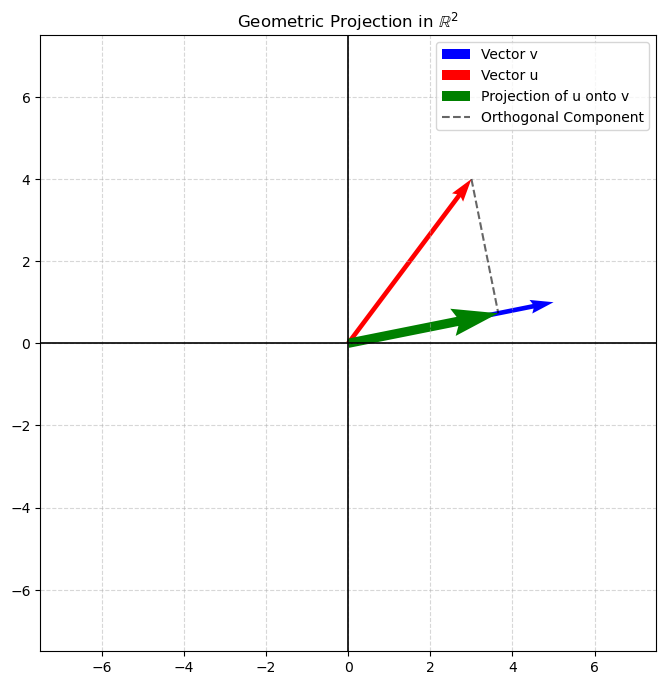

In [14]:
import numpy as np
import matplotlib.pyplot as plt

def projection(u, v):
    """Compute projection of u onto v."""
    return (np.dot(u, v) / np.dot(v, v)) * v

def visualize_projection(u, v, proj_uv):
    """
    Visualizes vector u, vector v, and projection of u onto v.
    """
    plt.figure(figsize=(8, 8))
    ax = plt.gca()

    # Plot vector v (blue)
    ax.quiver(0, 0, v[0], v[1],
              angles='xy', scale_units='xy', scale=1,
              color='blue', label='Vector v')

    # Plot vector u (red)
    ax.quiver(0, 0, u[0], u[1],
              angles='xy', scale_units='xy', scale=1,
              color='red', label='Vector u')

    # Plot projected vector (green)
    ax.quiver(0, 0, proj_uv[0], proj_uv[1],
              angles='xy', scale_units='xy', scale=1,
              color='green', width=0.015,
              label='Projection of u onto v')

    # Orthogonal drop line
    plt.plot([u[0], proj_uv[0]],
             [u[1], proj_uv[1]],
             'k--', alpha=0.6,
             label='Orthogonal Component')

    # Dynamic axis scaling
    max_val = max(
        np.max(np.abs(u)),
        np.max(np.abs(v)),
        np.max(np.abs(proj_uv))
    ) * 1.5

    plt.xlim(-max_val, max_val)
    plt.ylim(-max_val, max_val)

    plt.axhline(0, color='black', lw=1.2)
    plt.axvline(0, color='black', lw=1.2)
    plt.grid(True, linestyle='--', alpha=0.5)
    plt.legend()
    plt.title(r'Geometric Projection in $\mathbb{R}^2$')
    plt.gca().set_aspect('equal', 'box')

    plt.show()


# Example execution
u_vector = np.array([3, 4])
v_vector = np.array([5, 1])

projected_vector = projection(u_vector, v_vector)

print("Projection:", projected_vector)

visualize_projection(u_vector, v_vector, projected_vector)

### Analysis of the Plotting Framework 

The `plt.quiver` function is structurally designed for mapping 2D vectors directly onto a standardized Cartesian plane. The inclusion of the strict parameters `angles='xy', scale_units='xy', scale=1` is mathematically critical; without them, matplotlib will automatically attempt to scale the arrows based on bounding box aesthetics rather than true mathematical values. These parameters ensure that the arrows explicitly reflect the exact physical cartesian dimensions, maintaining true mathematical length and angle integrity relative to the grid.   
<br>
By plotting the dashed "orthogonal path" connecting the extreme tip of vector $\mathbf{u}$ to the extreme tip of the newly projected vector, the visualization explicitly proves the theorem of orthogonality: the error vector (which is the mathematical difference between the original vector and its projection) is perfectly perpendicular to the target vector $\mathbf{v}$. In the broader context of deep learning, this dashed line visually represents the minimal distance an optimization algorithm would need to travel to mathematically project a parameter onto a constrained subspace.


## Synthesis : Connecting Geometric Foundations to Deep Learning Architectures

The transition from raw mathematical abstractions to applied artificial intelligence models is absolutely seamless. A neural network is fundamentally nothing more than a highly orchestrated sequence of geometric transformations operating upon bounded topological manifolds. The theories of vector spaces, norms, and dot products dictate every calculation from the input layer to the final loss scalar.

When a language model processes text, it does not interpret characters; it projects discrete semantic tokens into an expansive n-dimensional basis. The span of this geometric basis explicitly determines the model's vocabulary and cognitive capacity. The vectors encode relationships entirely through spatial positioning and coordinate geometry. As these embeddings move through the network, the model distinguishes relevant features from noise by leveraging the dot product. In modern transformer architectures, self-attention mechanisms evaluate millions of queries and keys using dot products, scaling signal strength based strictly on the angular alignment (cosine similarity) and absolute magnitude of these high-dimensional vectors.   

As the model learns, it navigates a vast topological landscape dictated by its loss function. The strategic application of L 
1
​
  or L 
2
​
  norms physically sculpts this optimization landscape. An L 
1
​
  constraint creates a rigid, diamond-shaped geometric boundary that naturally zeroes out redundant weights upon intersection, yielding sparse, computationally efficient models perfectly suited for variable selection. An L 
2
​
  constraint creates a smooth, spherical basin that symmetrically shrinks all parameters without zeroing them, heavily enhancing generalization and robustness across unseen data points.   

To prevent systemic failure during training, weight matrices are frequently initialized using strict orthogonal constraints. By enforcing perfect perpendicularity (90 
∘
  separation) between parameter vectors, the model mathematically achieves dynamical isometry. This guarantees that backpropagating signals—the literal lifeblood of learning—do not geometrically collapse to zero or explode to infinity across deep layers. Concurrently, orthogonality losses can be applied to force the network to learn entirely unique, non-redundant feature representations, pushing filters apart on the surface of a hypersphere to maximize spatial diversity.   

Finally, the physical descent down this heavily sculpted loss landscape is driven explicitly by the calculus of directional derivatives and Taylor expansions. Gradient descent functions not by arbitrary estimation or heuristic guessing, but by rigorously minimizing the dot product between the gradient and the step trajectory. By maintaining a strict π radian (180 
∘
 ) angular offset from the gradient, the optimizer mathematically guarantees the steepest possible topological path to convergence.   

Ultimately, the mastery of deep learning relies not merely on importing software frameworks or high-level APIs, but on possessing an exhaustive, rigorous comprehension of the underlying topological, algebraic, and geometric truths. Every parameter update, every neural activation, and every attention score is a pure expression of vector geometry.

